# Data

## Dataset Overview

In [39]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(rstatix)
source("config.R")

In [2]:
marketing.data <- read.csv(MARKETING_DATA)

str(marketing.data)

'data.frame':	588101 obs. of  7 variables:
 $ X            : int  0 1 2 3 4 5 6 7 8 9 ...
 $ user.id      : int  1069124 1119715 1144181 1435133 1015700 1137664 1116205 1496843 1448851 1446284 ...
 $ test.group   : chr  "ad" "ad" "ad" "ad" ...
 $ converted    : chr  "False" "False" "False" "False" ...
 $ total.ads    : int  130 93 21 355 276 734 264 17 21 142 ...
 $ most.ads.day : chr  "Monday" "Tuesday" "Tuesday" "Tuesday" ...
 $ most.ads.hour: int  20 22 18 10 14 10 13 18 19 14 ...


In [3]:
marketing.data$converted <- as.logical(toupper(marketing.data$converted))

day.levels <- c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")
marketing.data$most.ads.day <- factor(marketing.data$most.ads.day, levels = day.levels, ordered = TRUE)

marketing.data$test.group <- factor(marketing.data$test.group, levels = c("psa", "ad"))

summary(marketing.data)

       X             user.id        test.group   converted      
 Min.   :     0   Min.   : 900000   psa: 23524   Mode :logical  
 1st Qu.:147025   1st Qu.:1143190   ad :564577   FALSE:573258   
 Median :294050   Median :1313725                TRUE :14843    
 Mean   :294050   Mean   :1310692                               
 3rd Qu.:441075   3rd Qu.:1484088                               
 Max.   :588100   Max.   :1654483                               
                                                                
   total.ads          most.ads.day   most.ads.hour  
 Min.   :   1.00   Monday   :87073   Min.   : 0.00  
 1st Qu.:   4.00   Tuesday  :77479   1st Qu.:11.00  
 Median :  13.00   Wednesday:80908   Median :14.00  
 Mean   :  24.82   Thursday :82982   Mean   :14.47  
 3rd Qu.:  27.00   Friday   :92608   3rd Qu.:18.00  
 Max.   :2065.00   Saturday :81660   Max.   :23.00  
                   Sunday   :85391                  

In [4]:
missing.idx <- which(!complete.cases(marketing.data))
length(missing.idx)

[1] 0

# Exploratory Data Analysis

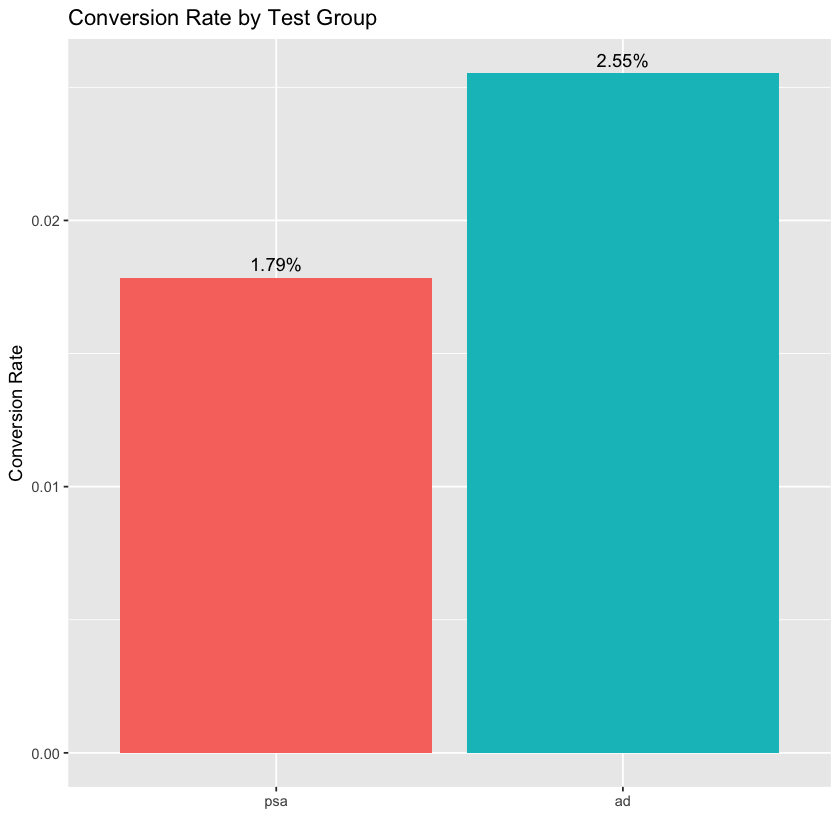

In [12]:
marketing.data %>%
  group_by(test.group) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = test.group, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = scales::percent(converted_rate, accuracy = 0.01)),
            vjust = -0.5) +
  labs(title = "Conversion Rate by Test Group",
       x = "", y = "Conversion Rate") +
  theme(legend.position = "none")


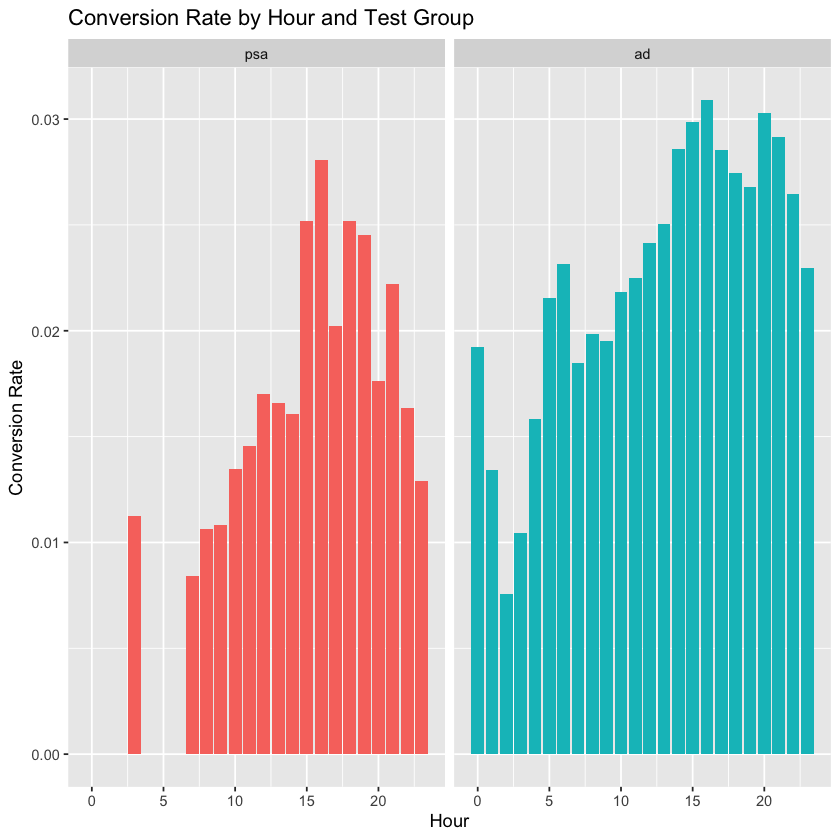

In [ ]:
marketing.data %>%
  group_by(test.group, most.ads.hour) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.hour, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ test.group) +
  labs(title = "Conversion Rate by Hour and Test Group", x = "Hour", y = "Conversion Rate") +
  theme(legend.position = "none")·

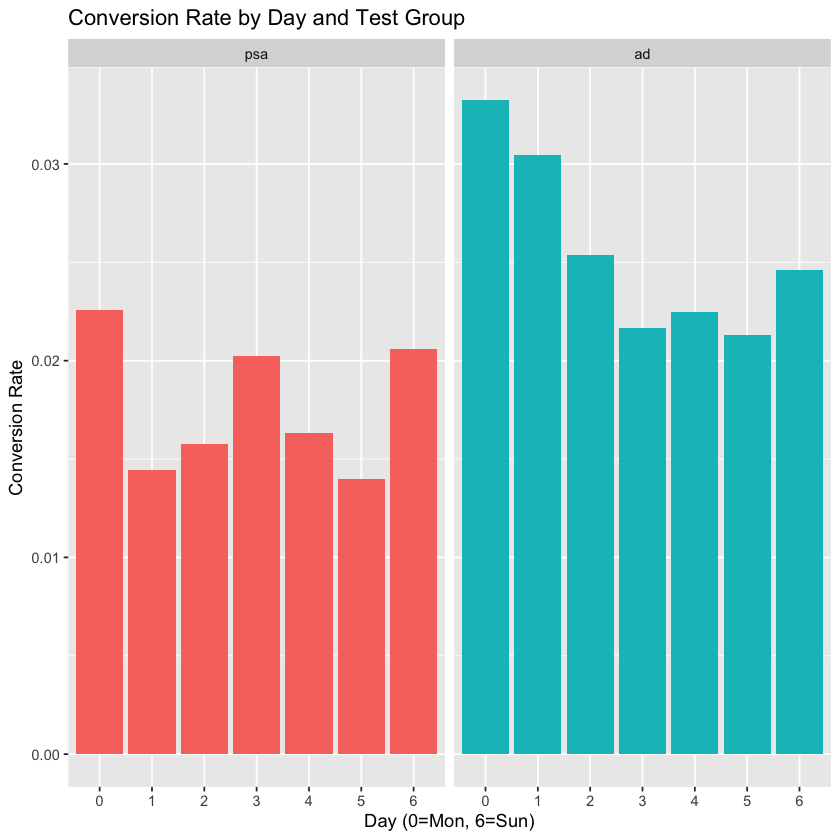

In [ ]:
marketing.data %>%
  group_by(test.group, most.ads.day) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.day, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ test.group) +
  scale_x_discrete(labels = 0:6) +
  labs(title = "Conversion Rate by Day and Test Group", x = "Day (0=Mon, 6=Sun)", y = "Conversion Rate") +
  theme(legend.position = "none")

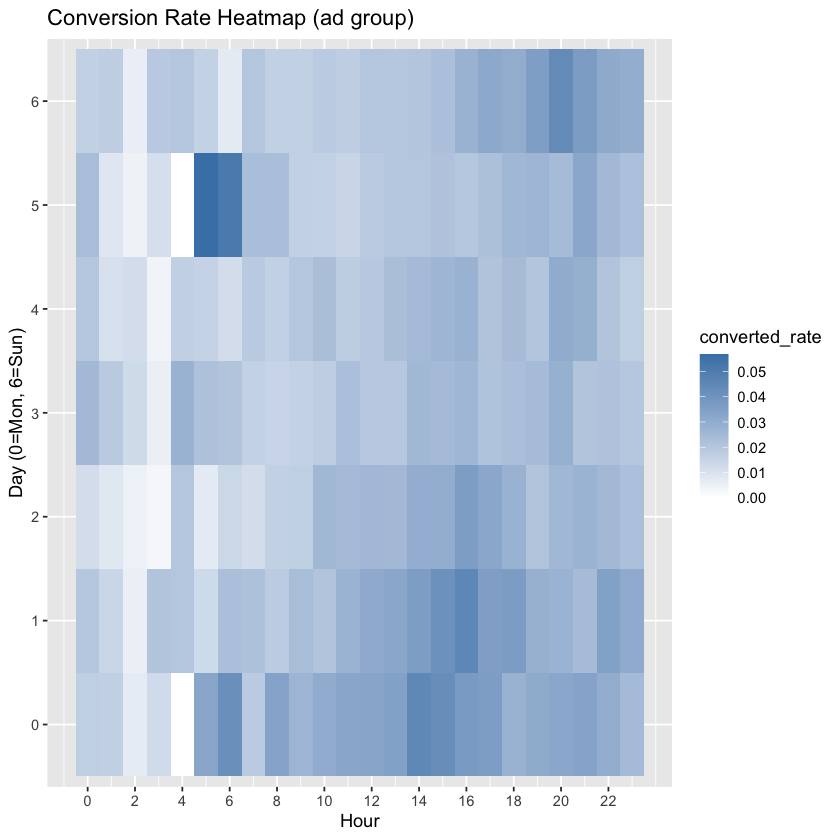

In [37]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day, most.ads.hour) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.hour, y = most.ads.day, fill = converted_rate)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  scale_x_continuous(breaks = seq(0, 23, by = 2)) +
  scale_y_discrete(labels = 0:6) +
  labs(title = "Conversion Rate Heatmap (ad group)", x = "Hour", y = "Day (0=Mon, 6=Sun)")


Lower bound: -65 
Upper bound: 96 
Number of outliers: 24825 
Percentage: 4.22 %


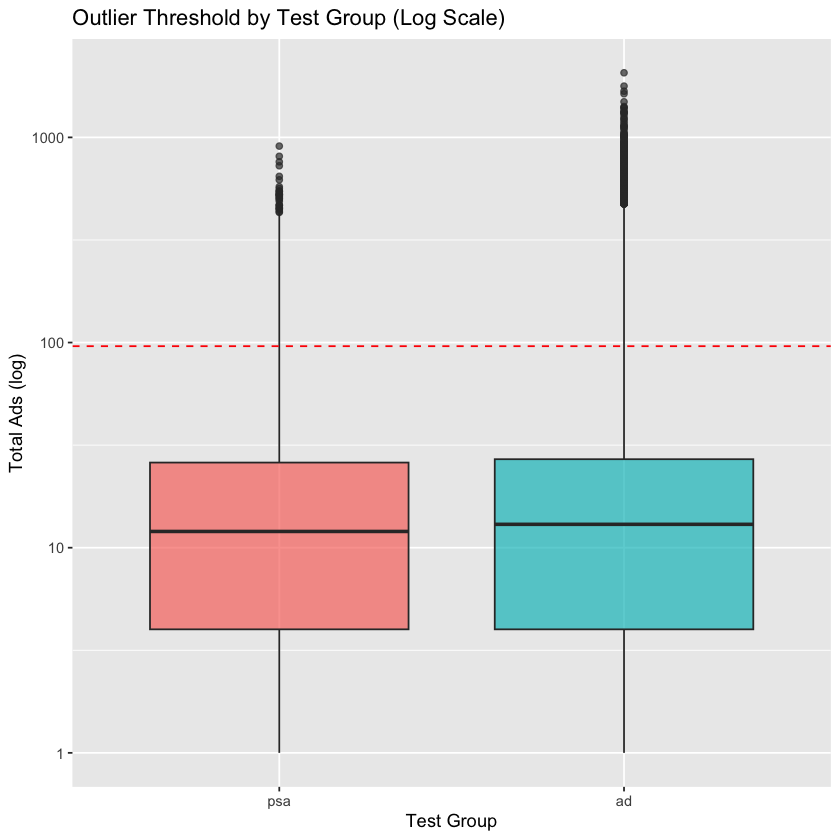

In [32]:
Q1 <- quantile(marketing.data$total.ads, 0.25)
Q3 <- quantile(marketing.data$total.ads, 0.75)
IQR_val <- Q3 - Q1

lower_bound <- Q1 - 3 * IQR_val
upper_bound <- Q3 + 3 * IQR_val

outliers <- marketing.data[marketing.data$total.ads > upper_bound, ]

cat("Lower bound:", lower_bound, "\n")
cat("Upper bound:", upper_bound, "\n")
cat("Number of outliers:", nrow(outliers), "\n")
cat("Percentage:", round(nrow(outliers) / nrow(marketing.data) * 100, 2), "%\n")

ggplot(marketing.data, aes(x = test.group, y = total.ads, fill = test.group)) +
  geom_boxplot(alpha = 0.7) +
  geom_hline(yintercept = upper_bound, color = "red", linetype = "dashed") +
  scale_y_log10() +
  labs(title = "Outlier Threshold by Test Group (Log Scale)",
       x = "Test Group", y = "Total Ads (log)") +
  theme(legend.position = "none")



# Frequentist A/B Testing

In [ ]:
table.converted <- table(test.group = marketing.data$test.group, 
                         converted = marketing.data$converted)
prop.test(table.converted[, c("TRUE", "FALSE")])


	2-sample test for equality of proportions with continuity correction

data:  table.converted[, c("TRUE", "FALSE")]
X-squared = 54.006, df = 1, p-value = 1.999e-13
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.009456114 -0.005928792
sample estimates:
    prop 1     prop 2 
0.01785411 0.02554656 
